## 1. Install & Import

In [1]:
# cell : 01
# install extra packages that are not available by default in colab
!pip install mlxtend -q
!pip install xgboost -q
!pip install openpyxl -q

print("packages installed")

packages installed


In [2]:
# cell : 02
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, BaggingClassifier,
                               VotingClassifier, StackingClassifier,
                               IsolationForest)
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("all libraries imported successfully")

all libraries imported successfully


## 2. Load Data

In [3]:
# cell : 03
from google.colab import files

print("upload the online_retail_II.xlsx or .csv file")
uploaded = files.upload()

upload the online_retail_II.xlsx or .csv file


Saving online_retail_II.xlsx to online_retail_II.xlsx


In [4]:
# cell : 04
file_name = list(uploaded.keys())[0]

if file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name, sheet_name=None)
    df = pd.concat(df.values(), ignore_index=True)
elif file_name.endswith('.csv'):
    df = pd.read_csv(file_name, encoding='unicode_escape')
else:
    print("unsupported format, please upload .xlsx or .csv")

print("dataset loaded")
print("shape:", df.shape)
print("\ncolumns:", list(df.columns))

dataset loaded
shape: (1067371, 8)

columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
# cell : 05
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
# cell : 06
print("dataset info:")
df.info()

dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
# cell : 07
print("statistical summary:")
df.describe()

statistical summary:


,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


## 3. Data Preprocessing

Check and handle missing values, remove cancelled orders, fix data types, drop outliers.

In [8]:
# cell : 08
# STEP 1: Standardize Column Names

df_original = df.copy()

df.columns = df.columns.str.strip().str.replace(' ', '_')
print("columns after standardizing:", list(df.columns))

columns after standardizing: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']


In [9]:
# cell : 09
# STEP 2: Check Missing Values

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Missing %
Description           4382       0.41
Customer_ID         243007      22.77


In [10]:
# cell : 10
# STEP 3: Remove Rows with No Customer ID

customer_col = [col for col in df.columns if 'customer' in col.lower()][0]

before = len(df)
df = df.dropna(subset=[customer_col])
print("removed rows with missing customer id:", before - len(df))
print("remaining rows:", len(df))

removed rows with missing customer id: 243007
remaining rows: 824364


In [11]:
# cell : 11
# STEP 4: Separate Cancelled Orders

invoice_col = [col for col in df.columns if 'invoice' in col.lower()][0]
df[invoice_col] = df[invoice_col].astype(str)

df_cancelled = df[df[invoice_col].str.startswith('C')].copy()
df = df[~df[invoice_col].str.startswith('C')].copy()

print("cancelled orders:", len(df_cancelled))
print("valid orders:", len(df))

cancelled orders: 18744
valid orders: 805620


In [12]:
# cell : 12
# STEP 5: Remove Negative / Zero Quantity and Price

quantity_col = [col for col in df.columns if 'quantity' in col.lower()][0]
price_col    = [col for col in df.columns if 'price' in col.lower()][0]
date_col     = [col for col in df.columns if 'date' in col.lower()][0]
desc_col     = [col for col in df.columns if 'description' in col.lower()][0]
country_col  = [col for col in df.columns if 'country' in col.lower()][0]

df = df[df[quantity_col] > 0]
df = df[df[price_col] > 0]

print("rows after cleaning:", len(df))

rows after cleaning: 805549


In [13]:
# cell : 13
# STEP 6: Fix Data Types

df[date_col] = pd.to_datetime(df[date_col])
df[customer_col] = df[customer_col].astype(int).astype(str)

print("data types after fixing:")
print(df.dtypes)

data types after fixing:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer_ID            object
Country                object
dtype: object


In [14]:
# cell : 14
# STEP 7: Remove Outliers (IQR method)

def remove_outliers(data, col, multiplier=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - multiplier * IQR) & (data[col] <= Q3 + multiplier * IQR)]

before = len(df)
df = remove_outliers(df, quantity_col)
df = remove_outliers(df, price_col)

print("outlier rows removed:", before - len(df))
print("final dataset shape:", df.shape)

outlier rows removed: 118785
final dataset shape: (686764, 8)


## 4. Feature Engineering (RFM)

In [15]:
# cell : 15
# STEP 1: Create TotalPrice

df['TotalPrice'] = df[quantity_col] * df[price_col]

print("TotalPrice column created")
print("min:", df['TotalPrice'].min())
print("max:", df['TotalPrice'].max())
print("mean:", round(df['TotalPrice'].mean(), 2))

TotalPrice column created
min: 0.001
max: 182.25
mean: 12.85


In [16]:
# cell : 16
# STEP 2: Create Time-Based Features

df['Year']      = df[date_col].dt.year
df['Month']     = df[date_col].dt.month
df['DayOfWeek'] = df[date_col].dt.dayofweek
df['DayName']   = df[date_col].dt.day_name()
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

print("time features created: Year, Month, DayOfWeek, DayName, IsWeekend")

time features created: Year, Month, DayOfWeek, DayName, IsWeekend


In [17]:
# cell : 17
# STEP 3: RFM Calculation

reference_date = df[date_col].max() + pd.Timedelta(days=1)
print("reference date:", reference_date.date())

rfm = df.groupby(customer_col).agg(
    Recency   = (date_col,     lambda x: (reference_date - x.max()).days),
    Frequency = (invoice_col,  'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM dataset shape:", rfm.shape)
rfm.head(10)

reference date: 2011-12-10
RFM dataset shape: (5675, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,529,11,372.86
1,12347,2,8,4538.90
2,12348,249,4,312.36
3,12349,19,3,2635.04
4,12350,310,1,294.40
5,12351,375,1,288.18
6,12352,36,9,1461.99
7,12353,204,2,347.06
8,12354,232,1,682.69
9,12355,214,2,656.11


In [18]:
# cell : 18
# STEP 4: RFM Scores and Segments

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5])

rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:   return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2:            return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2: return 'Lost'
    elif r <= 2 and f >= 4:            return 'Cannot Lose Them'
    else:                              return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# target variable for classification
rfm['HighValue'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

print("RFM segments:")
print(rfm['Segment'].value_counts())

RFM segments:
Segment
Champions           1240
Lost                1204
Loyal Customers     1088
Others              1079
At Risk              593
New Customers        445
Cannot Lose Them      26
Name: count, dtype: int64


## 5. Exploratory Data Analysis

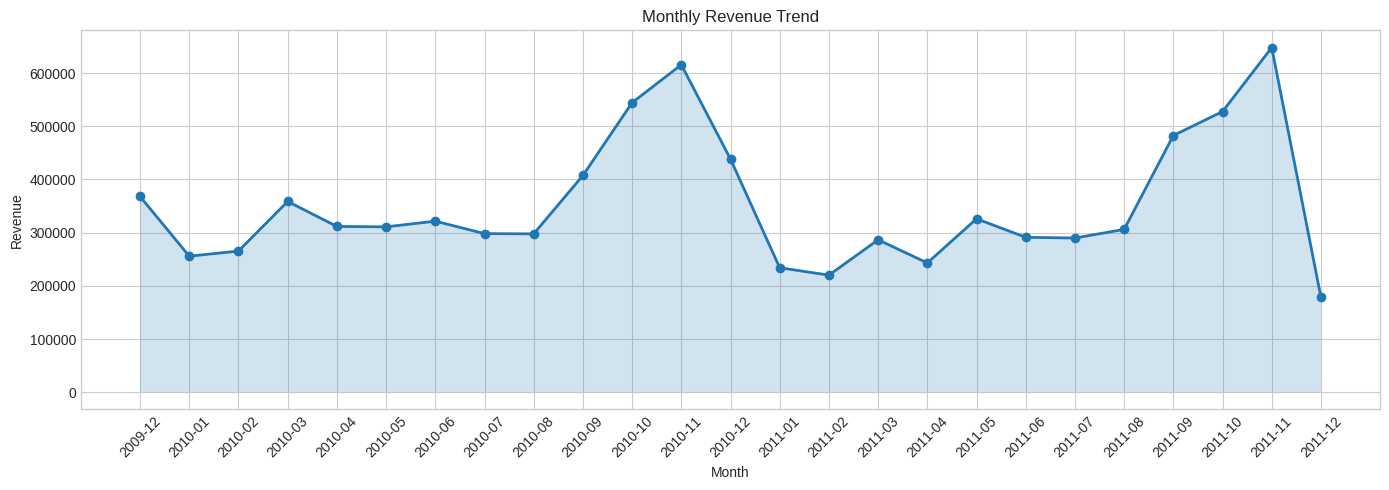

In [19]:
# cell : 19
# monthly revenue trend

monthly_sales = df.groupby(df[date_col].dt.to_period('M'))['TotalPrice'].sum().reset_index()
monthly_sales.columns = ['Month', 'Revenue']
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o', linewidth=2)
plt.fill_between(range(len(monthly_sales)), monthly_sales['Revenue'], alpha=0.2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

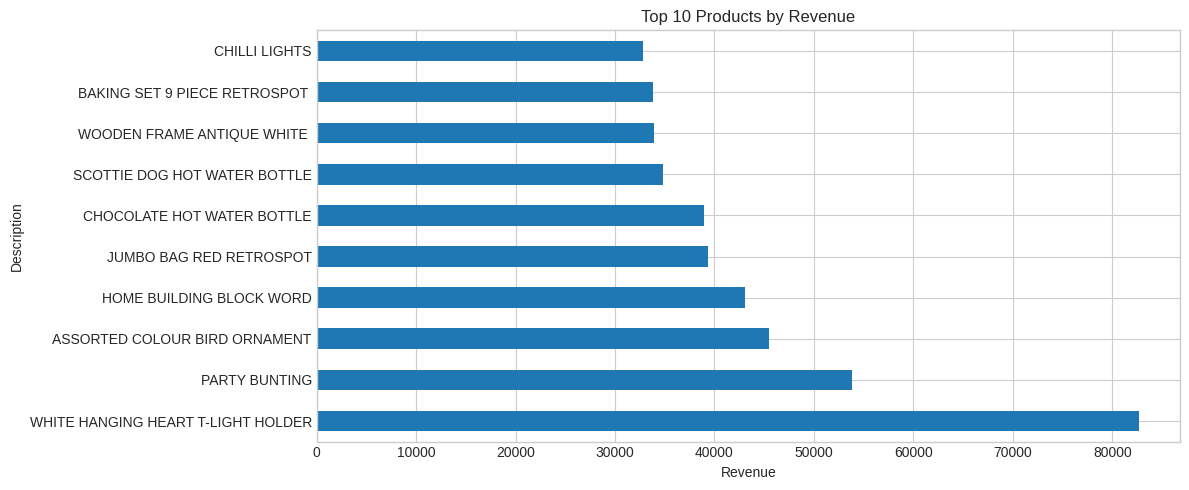

In [20]:
# cell : 20
# top 10 products by revenue

top_products = df.groupby(desc_col)['TotalPrice'].sum().nlargest(10)

plt.figure(figsize=(12,5))
top_products.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

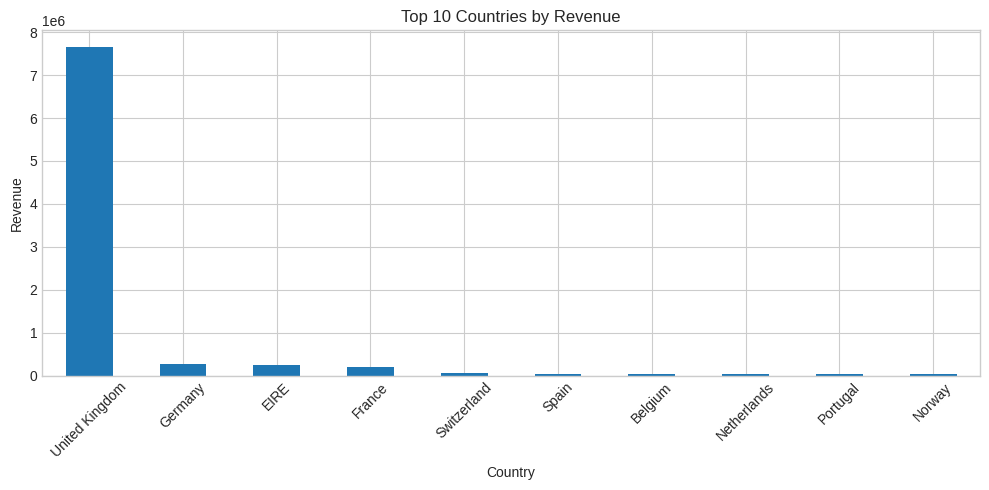

In [21]:
# cell : 21
# top 10 countries
top_countries = df.groupby(country_col)['TotalPrice'].sum().nlargest(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

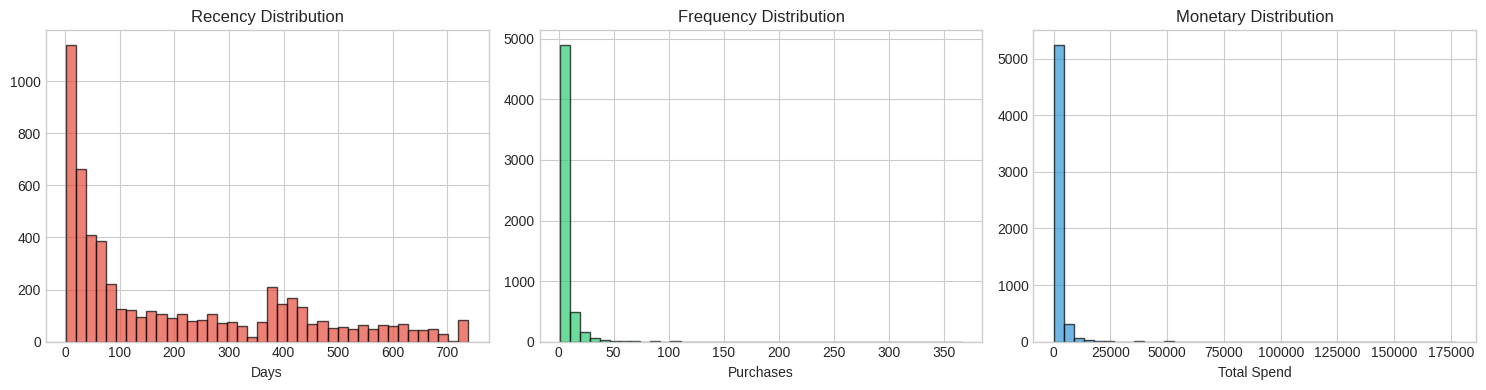

In [22]:
# cell : 22
# RFM distributions

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(rfm['Recency'],   bins=40, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Purchases')

axes[2].hist(rfm['Monetary'],  bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()

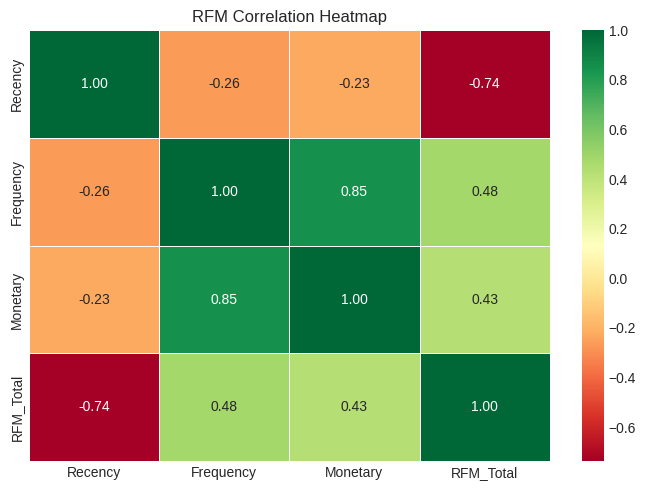

In [23]:
# cell : 23
# correlation heatmap

plt.figure(figsize=(7,5))
sns.heatmap(rfm[['Recency','Frequency','Monetary','RFM_Total']].corr(),
            annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('RFM Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
# cell : 24
# EDA summary

print("Total Revenue:      ", round(df['TotalPrice'].sum(), 2))
print("Unique Customers:   ", df[customer_col].nunique())
print("Unique Products:    ", df[desc_col].nunique())
print("Countries:          ", df[country_col].nunique())
print("Date Range:         ", df[date_col].min().date(), "to", df[date_col].max().date())

Total Revenue:       8825609.21
Unique Customers:    5675
Unique Products:     4835
Countries:           41
Date Range:          2009-12-01 to 2011-12-09


## 6. Dimensionality Reduction (PCA)

In [25]:
# cell : 25

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("data scaled, shape:", rfm_scaled.shape)

data scaled, shape: (5675, 3)


In [26]:
# cell : 26

pca = PCA()
pca_result = pca.fit_transform(rfm_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("PCA Explained Variance:")
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {ev*100:.2f}%  (cumulative: {cv*100:.2f}%)")

PCA Explained Variance:
  PC1: 65.79%  (cumulative: 65.79%)
  PC2: 29.25%  (cumulative: 95.04%)
  PC3: 4.96%  (cumulative: 100.00%)


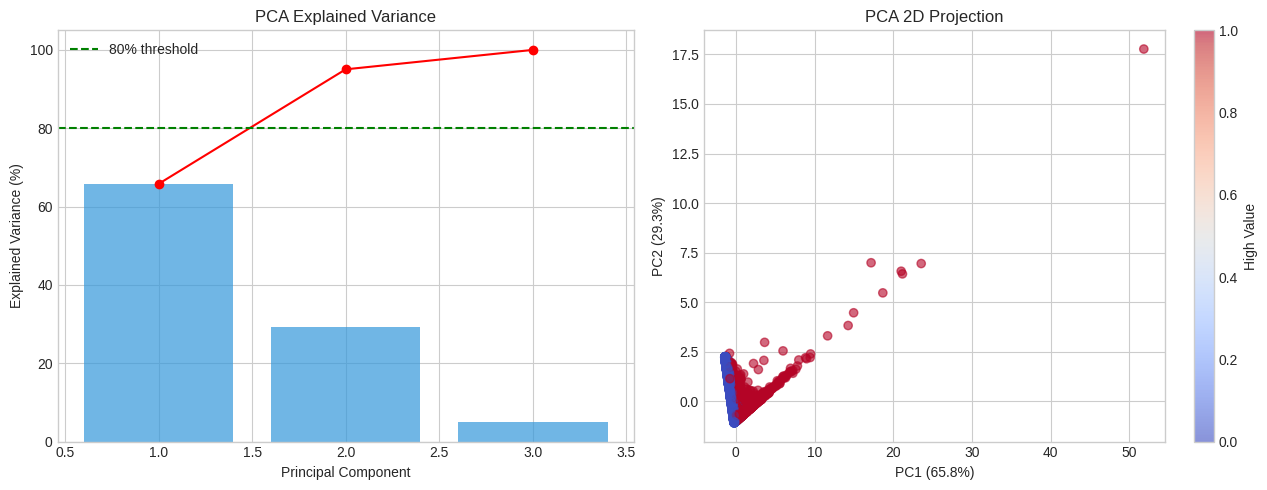

In [27]:
# cell : 27

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].bar(range(1, len(explained)+1), explained*100, color='#3498db', alpha=0.7)
axes[0].plot(range(1, len(cumulative)+1), cumulative*100, 'ro-')
axes[0].axhline(y=80, color='g', linestyle='--', label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()

scatter = axes[1].scatter(pca_result[:, 0], pca_result[:, 1],
                          c=rfm['HighValue'], cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].set_title('PCA 2D Projection')
plt.colorbar(scatter, ax=axes[1], label='High Value')

plt.tight_layout()
plt.show()

## 7. Association Rule Mining (FP-Growth)

In [28]:
# cell : 28
# Prepare Basket Data

print("preparing basket data...")

basket = (df.groupby([invoice_col, desc_col])[quantity_col]
            .sum()
            .unstack()
            .fillna(0)
            .reset_index()
            .set_index(invoice_col))

# sample if too large
if basket.shape[0] > 10000:
    basket = basket.sample(n=10000, random_state=42)

# encode to binary
basket = basket.applymap(lambda x: 1 if x >= 1 else 0)

print("basket shape:", basket.shape)

preparing basket data...
basket shape: (10000, 4835)


In [29]:
# cell : 29
# FP-Growth

frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)
print("frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
strong_rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.5)]

print("total rules:", len(rules))
print("strong rules (confidence>=0.3, lift>=1.5):", len(strong_rules))

frequent itemsets found: 692
total rules: 384
strong rules (confidence>=0.3, lift>=1.5): 278


In [30]:
# cell : 30
# top 10 rules by lift

top_rules = rules.nlargest(10, 'lift')[['antecedents','consequents','support','confidence','lift']]
top_rules

,antecedents,consequents,support,confidence,lift
319,"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",(POPPY'S PLAYHOUSE LIVINGROOM ),0.0102,0.755556,53.968254
322,(POPPY'S PLAYHOUSE LIVINGROOM ),"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",0.0102,0.728571,53.968254
320,"(POPPY'S PLAYHOUSE LIVINGROOM , POPPY'S PLAYHO...",(POPPY'S PLAYHOUSE BEDROOM ),0.0102,0.850000,53.125000
321,(POPPY'S PLAYHOUSE BEDROOM ),"(POPPY'S PLAYHOUSE LIVINGROOM , POPPY'S PLAYHO...",0.0102,0.637500,53.125000
318,"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",(POPPY'S PLAYHOUSE KITCHEN),0.0102,0.902655,51.580278
323,(POPPY'S PLAYHOUSE KITCHEN),"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",0.0102,0.582857,51.580278
316,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE LIVINGROOM ),0.0113,0.706250,50.446429
317,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE BEDROOM ),0.0113,0.807143,50.446429
314,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.0120,0.857143,48.979592
315,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE LIVINGROOM ),0.0120,0.685714,48.979592


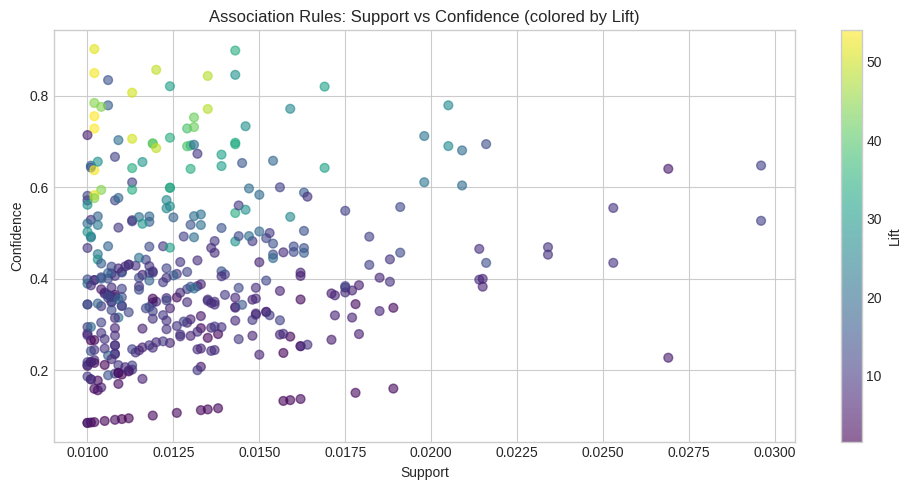

In [31]:
# cell : 31
# support vs confidence scatter

plt.figure(figsize=(10,5))
scatter = plt.scatter(rules['support'], rules['confidence'],
                      c=rules['lift'], cmap='viridis', alpha=0.6, s=40)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (colored by Lift)')
plt.tight_layout()
plt.show()

## 8. Customer Segmentation (Clustering)

In [32]:
# cell : 32
# Find Optimal K — Elbow + Silhouette

clustering_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustering_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(clustering_scaled, km.labels_))
    print(f"K={k}  inertia={km.inertia_:.2f}  silhouette={sil_scores[-1]:.4f}")

K=2  inertia=11911.41  silhouette=0.5160
K=3  inertia=7379.61  silhouette=0.5307
K=4  inertia=4801.23  silhouette=0.5784
K=5  inertia=3553.79  silhouette=0.5787
K=6  inertia=2760.17  silhouette=0.5478
K=7  inertia=2189.90  silhouette=0.5130
K=8  inertia=1834.77  silhouette=0.4850
K=9  inertia=1591.85  silhouette=0.4751
K=10  inertia=1430.94  silhouette=0.4597


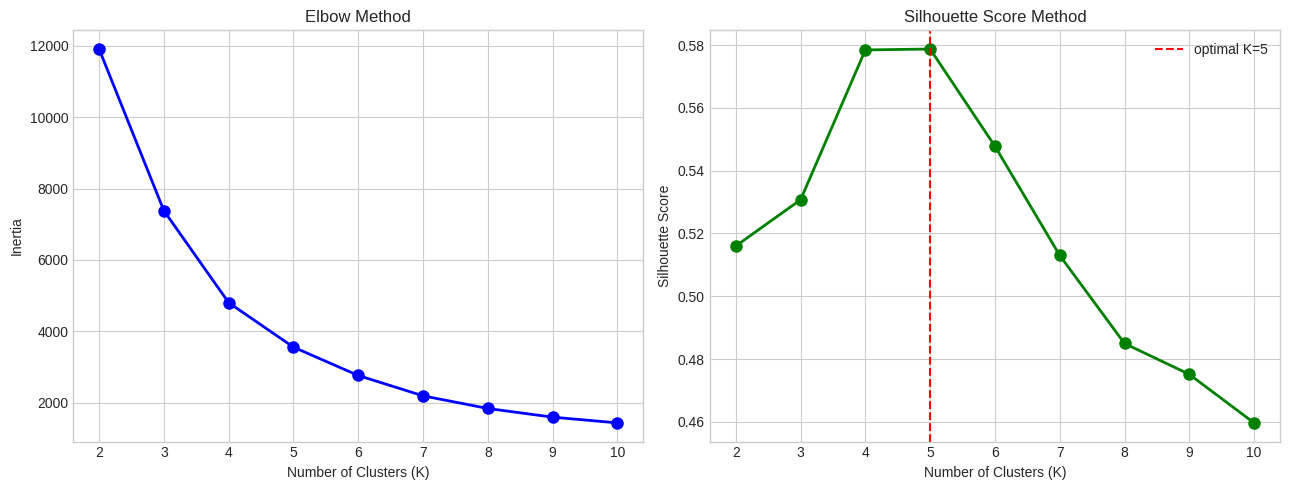

optimal K: 5


In [33]:
# cell : 33

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score Method')

optimal_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'optimal K={optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("optimal K:", optimal_k)

In [34]:
# cell : 34
# K-Means with Optimal K

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(clustering_scaled)

print("K-Means cluster distribution:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())

K-Means cluster distribution:
KMeans_Cluster
0    3419
1    1885
2       8
3     362
4       1
Name: count, dtype: int64


In [35]:
# cell : 35
# cluster profiles

cluster_profile = rfm.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_profile['Count'] = rfm['KMeans_Cluster'].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
0,73.43,5.08,1258.18,3419
1,466.04,2.10,466.99,1885
2,49.88,174.25,46285.58,8
3,26.39,28.32,8552.72,362
4,1.00,367.00,177257.62,1


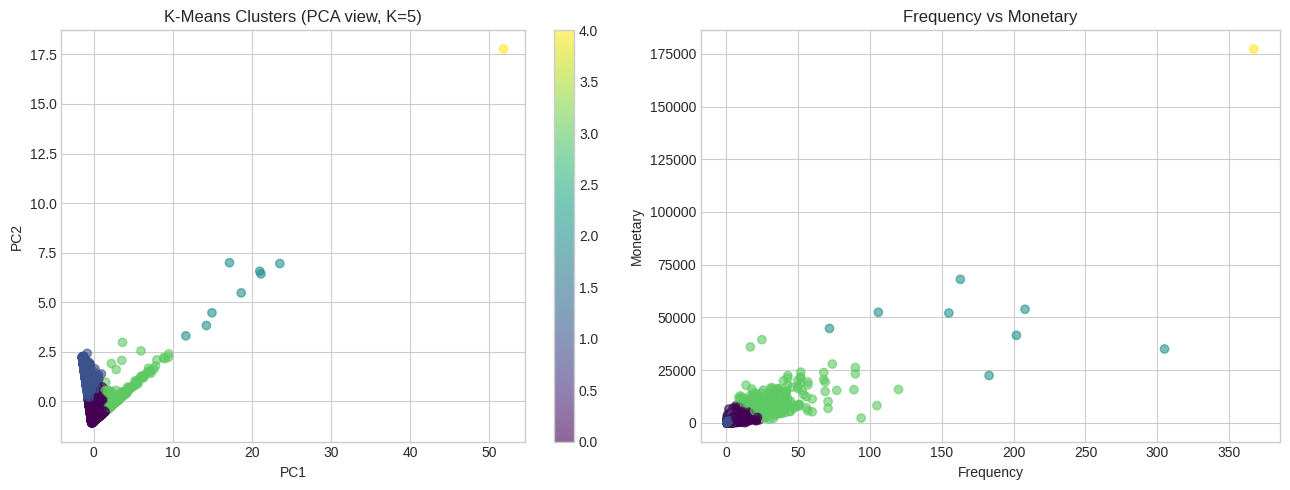

In [36]:
# cell : 36
# visualize clusters (PCA view)

pca_2d = PCA(n_components=2)
pca_vis = pca_2d.fit_transform(clustering_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

scatter = axes[0].scatter(pca_vis[:,0], pca_vis[:,1], c=rfm['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means Clusters (PCA view, K={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0])

axes[1].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[1].set_title('Frequency vs Monetary')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')

plt.tight_layout()
plt.show()

In [37]:
# cell : 37
# DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(clustering_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise    = (rfm['DBSCAN_Cluster'] == -1).sum()

print("DBSCAN clusters found:", n_clusters)
print("noise points:", n_noise, f"({n_noise/len(rfm)*100:.1f}%)")

DBSCAN clusters found: 1
noise points: 83 (1.5%)


## 9. Classification Models

In [38]:
# cell : 38
# Prepare Data

X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
y = rfm['HighValue'].copy()

scaler_cls = StandardScaler()
X_scaled = scaler_cls.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("training samples:", X_train.shape[0])
print("testing samples: ", X_test.shape[0])

training samples: 4540
testing samples:  1135


In [39]:
# cell : 39
# Train and Evaluate Models

models = {
    'Logistic Regression':   LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':         DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':         RandomForestClassifier(random_state=42, n_estimators=100),
    'KNN':                   KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':           GaussianNB(),
    'SVM':                   SVC(random_state=42, probability=True),
    'Gradient Boosting':     GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba)
    })

    print(f"{name}  —  accuracy: {results[-1]['Accuracy']:.4f}  f1: {results[-1]['F1-Score']:.4f}")

Logistic Regression  —  accuracy: 0.9806  f1: 0.9803
Decision Tree  —  accuracy: 1.0000  f1: 1.0000
Random Forest  —  accuracy: 1.0000  f1: 1.0000
KNN  —  accuracy: 0.9762  f1: 0.9762
Naive Bayes  —  accuracy: 0.9286  f1: 0.9242
SVM  —  accuracy: 0.9797  f1: 0.9794
Gradient Boosting  —  accuracy: 1.0000  f1: 1.0000


In [40]:
# cell : 40

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).round(4)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
6,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression,0.9806,0.9946,0.9665,0.9803,0.9985
5,SVM,0.9797,0.9945,0.9647,0.9794,0.9991
3,KNN,0.9762,0.9770,0.9753,0.9762,0.9949
4,Naive Bayes,0.9286,0.9841,0.8713,0.9242,0.9893


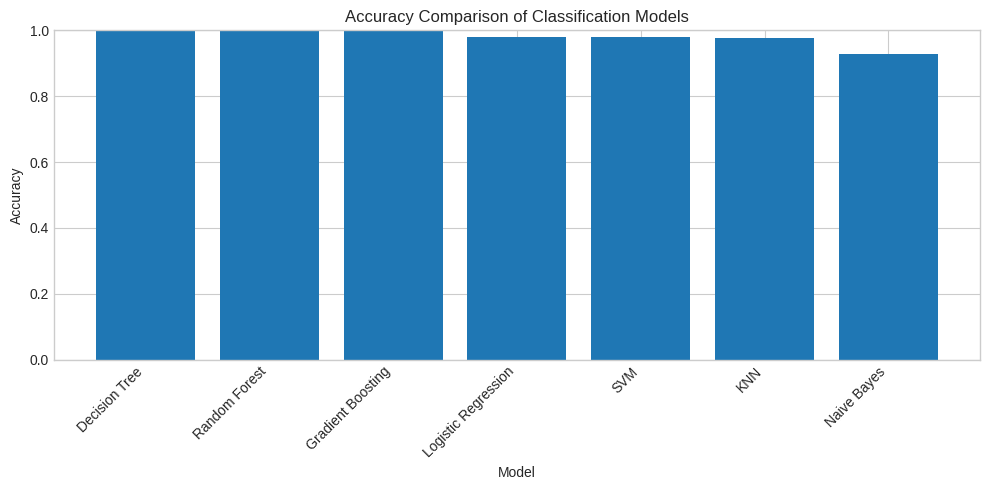

In [41]:
# cell : 41
# accuracy comparison bar chart

plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Classification Models')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

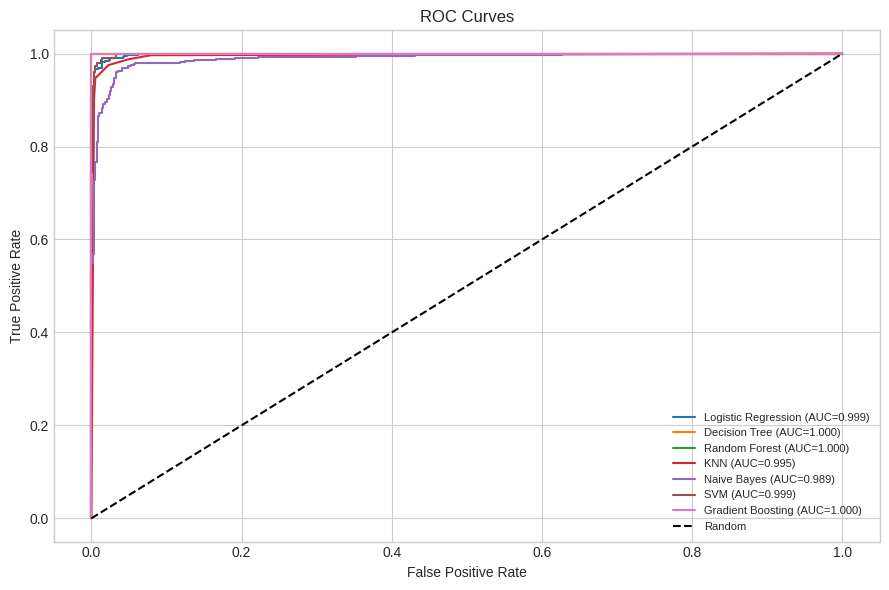

In [42]:
# cell : 42
# ROC curves

plt.figure(figsize=(9,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

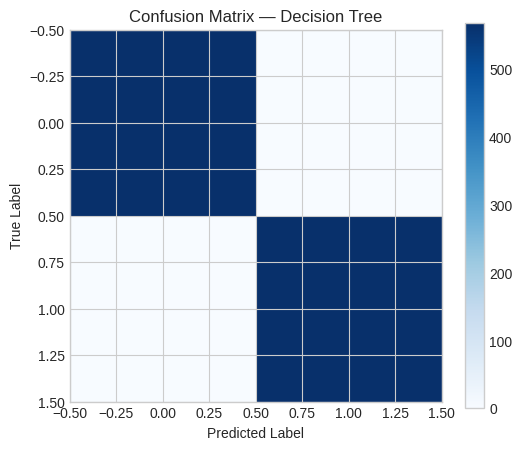

Classification Report:
              precision    recall  f1-score   support

   Low Value       1.00      1.00      1.00       568
  High Value       1.00      1.00      1.00       567

    accuracy                           1.00      1135
   macro avg       1.00      1.00      1.00      1135
weighted avg       1.00      1.00      1.00      1135



In [43]:
# cell : 43
# confusion matrix for best model

best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Value', 'High Value']))

## 10. Ensemble Learning

Bagging

In [44]:
# cell : 44

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bag))

Bagging Accuracy: 0.9991189427312775

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       568
           1       1.00      1.00      1.00       567

    accuracy                           1.00      1135
   macro avg       1.00      1.00      1.00      1135
weighted avg       1.00      1.00      1.00      1135



Boosting

In [45]:
# cell : 45

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_boost))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_boost))

AdaBoost Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       568
           1       1.00      1.00      1.00       567

    accuracy                           1.00      1135
   macro avg       1.00      1.00      1.00      1135
weighted avg       1.00      1.00      1.00      1135



Stacking

In [46]:
# cell : 46

base_learners = [
    ('rf',  RandomForestClassifier(random_state=42, n_estimators=100)),
    ('svm', SVC(random_state=42, probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

Stacking Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       568
           1       1.00      1.00      1.00       567

    accuracy                           1.00      1135
   macro avg       1.00      1.00      1.00      1135
weighted avg       1.00      1.00      1.00      1135



Ensemble Comparison

In [47]:
# cell : 47

ensemble_results = pd.DataFrame([
    {'Model': 'Bagging',  'Accuracy': accuracy_score(y_test, y_pred_bag),
     'F1-Score': f1_score(y_test, y_pred_bag)},
    {'Model': 'AdaBoost', 'Accuracy': accuracy_score(y_test, y_pred_boost),
     'F1-Score': f1_score(y_test, y_pred_boost)},
    {'Model': 'Stacking', 'Accuracy': accuracy_score(y_test, y_pred_stack),
     'F1-Score': f1_score(y_test, y_pred_stack)}
])

ensemble_results

,Model,Accuracy,F1-Score
0,Bagging,0.999119,0.999117
1,AdaBoost,1.000000,1.000000
2,Stacking,1.000000,1.000000


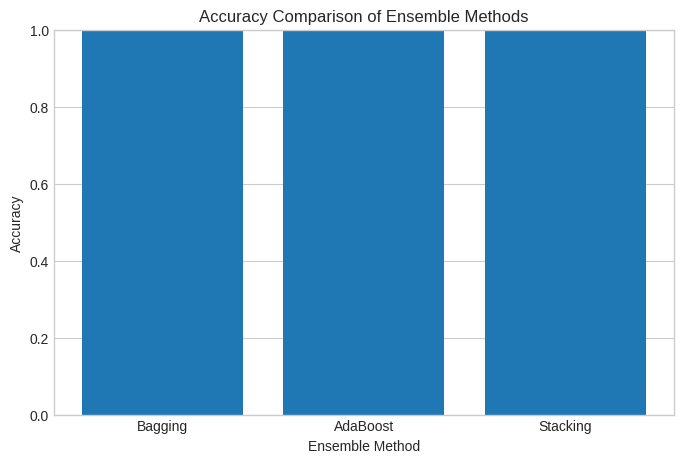

Best Ensemble: AdaBoost
Accuracy: 1.0


In [48]:
# cell : 48

plt.figure(figsize=(8,5))
plt.bar(ensemble_results['Model'], ensemble_results['Accuracy'])
plt.xlabel('Ensemble Method')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Ensemble Methods')
plt.ylim(0, 1)
plt.show()

best_ensemble = ensemble_results.loc[ensemble_results['Accuracy'].idxmax()]
print("Best Ensemble:", best_ensemble['Model'])
print("Accuracy:", best_ensemble['Accuracy'])

## 11. Anomaly Detection

In [49]:
# cell : 49

anomaly_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

Isolation Forest

In [50]:
# cell : 50

iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
rfm['Anomaly_IF'] = iso_forest.fit_predict(anomaly_scaled)
rfm['Anomaly_IF'] = rfm['Anomaly_IF'].map({1: 0, -1: 1})

n_if = rfm['Anomaly_IF'].sum()
print("Isolation Forest — anomalies detected:", n_if, f"({n_if/len(rfm)*100:.2f}%)")

Isolation Forest — anomalies detected: 284 (5.00%)


Local Outlier Factor

In [51]:
# cell : 51

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
rfm['Anomaly_LOF'] = lof.fit_predict(anomaly_scaled)
rfm['Anomaly_LOF'] = rfm['Anomaly_LOF'].map({1: 0, -1: 1})

n_lof = rfm['Anomaly_LOF'].sum()
print("LOF — anomalies detected:", n_lof, f"({n_lof/len(rfm)*100:.2f}%)")

LOF — anomalies detected: 284 (5.00%)


In [52]:
# cell : 52
# combined anomaly: both methods agree

rfm['Anomaly_Combined'] = ((rfm['Anomaly_IF'] + rfm['Anomaly_LOF']) == 2).astype(int)
n_combined = rfm['Anomaly_Combined'].sum()
print("Combined anomalies (both agree):", n_combined, f"({n_combined/len(rfm)*100:.2f}%)")

Combined anomalies (both agree): 95 (1.67%)


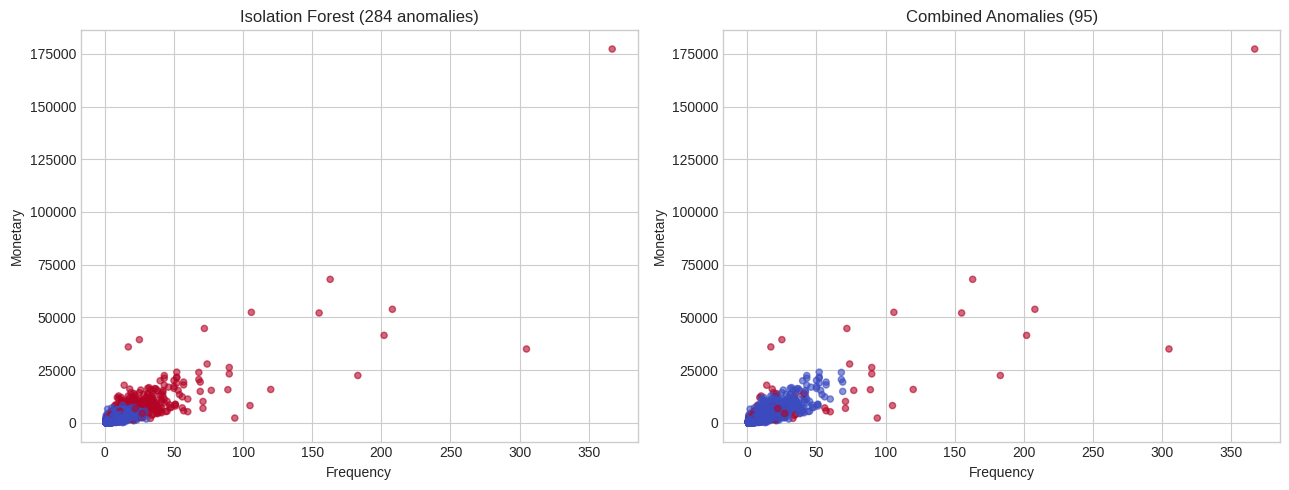

In [53]:
# cell : 53

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Anomaly_IF'],
                cmap='coolwarm', alpha=0.6, s=20)
axes[0].set_title(f'Isolation Forest ({n_if} anomalies)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')

axes[1].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Anomaly_Combined'],
                cmap='coolwarm', alpha=0.6, s=20)
axes[1].set_title(f'Combined Anomalies ({n_combined})')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')

plt.tight_layout()
plt.show()

In [54]:
# cell : 54
# anomalous customers

anomalies = rfm[rfm['Anomaly_Combined'] == 1][['CustomerID','Recency','Frequency','Monetary','Segment']]
print("top anomalous customers:")
anomalies.head(15)

top anomalous customers:


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,529,11,372.86,Cannot Lose Them
84,12433,1,10,12773.30,Champions
90,12439,683,2,1063.58,Others
127,12477,23,9,12039.71,Champions
132,12482,601,12,821.40,At Risk
187,12539,22,7,8070.10,Champions
382,12742,626,1,1080.56,Others
388,12748,1,305,35045.24,Champions
471,12835,428,40,5136.61,At Risk
479,12843,160,23,2985.10,Loyal Customers


## 12. Summary

In [58]:
# cell : 55

print("=" * 60)
print("            SUMMARY — InsightCart")
print("=" * 60)

print("\nDataset Overview")
print("-" * 40)
print("Original rows:    ", len(df_original))
print("Clean rows:       ", len(df))
print("Unique Customers: ", len(rfm))
print("Total Revenue:    ", round(df['TotalPrice'].sum(), 2))

print("\nAssociation Rules (FP-Growth)")
print("-" * 40)
print("Frequent Itemsets:", len(frequent_itemsets))
print("Total Rules:      ", len(rules))
print("Strong Rules:     ", len(strong_rules))

print("\nCustomer Segmentation (K-Means)")
print("-" * 40)
print("Optimal K:        ", optimal_k)
print("Silhouette Score: ", round(silhouette_score(clustering_scaled, rfm['KMeans_Cluster']), 4))
for seg, cnt in rfm['Segment'].value_counts().items():
    print(f"  {seg}: {cnt} ({cnt/len(rfm)*100:.1f}%)")

print("\nBest Classification Model")
print("-" * 40)
print("Model:    ", results_df.iloc[0]['Model'])
print("Accuracy: ", results_df.iloc[0]['Accuracy'])
print("F1-Score: ", results_df.iloc[0]['F1-Score'])
print("ROC-AUC:  ", results_df.iloc[0]['ROC-AUC'])

print("\nAnomaly Detection")
print("-" * 40)
print("Isolation Forest: ", n_if)
print("LOF:              ", n_lof)
print("Combined:         ", n_combined, f"({n_combined/len(rfm)*100:.2f}%)")

print("\n" + "=" * 60)
print("                  COMPLETED")
print("=" * 60)

            SUMMARY — InsightCart

Dataset Overview
----------------------------------------
Original rows:     1067371
Clean rows:        686764
Unique Customers:  5675
Total Revenue:     8825609.21

Association Rules (FP-Growth)
----------------------------------------
Frequent Itemsets: 692
Total Rules:       384
Strong Rules:      278

Customer Segmentation (K-Means)
----------------------------------------
Optimal K:         5
Silhouette Score:  0.5787
  Champions: 1240 (21.9%)
  Lost: 1204 (21.2%)
  Loyal Customers: 1088 (19.2%)
  Others: 1079 (19.0%)
  At Risk: 593 (10.4%)
  New Customers: 445 (7.8%)
  Cannot Lose Them: 26 (0.5%)

Best Classification Model
----------------------------------------
Model:     Decision Tree
Accuracy:  1.0
F1-Score:  1.0
ROC-AUC:   1.0

Anomaly Detection
----------------------------------------
Isolation Forest:  284
LOF:               284
Combined:          95 (1.67%)

                  COMPLETED


In [56]:
# cell : 56
# save results
rfm.to_csv('rfm_analysis_results.csv', index=False)
print("rfm results saved to rfm_analysis_results.csv")

from google.colab import files
files.download('rfm_analysis_results.csv')

rfm results saved to rfm_analysis_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>